In [20]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics.pairwise import cosine_similarity

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import itertools

In [21]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [33]:
df = pd.read_csv("df_merged.csv", encoding="cp949")
df = df.dropna()
print(f"데이터 로드 완료: {df.shape[0]:,}건, {df.shape[1]}개 컬럼")
print(f"고유 사용자: {df['idUser'].nunique():,}명")
print(f"고유 아이템: {df['ItemSmallName'].nunique()}개")

데이터 로드 완료: 854,101건, 34개 컬럼
고유 사용자: 3,000명
고유 아이템: 58개


In [37]:
# ItemSmallName에서 냉동이 포함된 주문의 비율
frozen_percentage = (df[df['ItemSmallName'].str.contains('냉동', na=False)]['idOrder'].nunique() / 
                     df['idOrder'].nunique()) * 100

print(f"전체 주문 수: {df['idOrder'].nunique()}")
print(f"냉동이 포함된 주문 수: {df[df['ItemSmallName'].str.contains('냉동', na=False)]['idOrder'].nunique()}")
print(f"냉동 포함율: {frozen_percentage:.2f}%")

전체 주문 수: 171029
냉동이 포함된 주문 수: 55919
냉동 포함율: 32.70%


In [23]:
# Cell 3: 글로벌 User-Item 행렬 구성
# ===================================================
# 전체 사용자(~3,000명) × 아이템(58개) 이진 구매 행렬

# User-Item 행렬 구성
global_matrix = (
    df.groupby(['idUser', 'ItemSmallName'])
    .size()
    .unstack(fill_value=0)
)
# 이진화: 1회 이상 구매 = 1, 미구매 = 0
global_matrix = (global_matrix > 0).astype(int)

print(f"글로벌 User-Item 행렬")
print(f"  사용자 수: {global_matrix.shape[0]:,}명")
print(f"  아이템 수: {global_matrix.shape[1]}개")
print(f"  Sparsity: {1 - global_matrix.values.mean():.2%}")
print(f"  평균 구매 아이템 수/사용자: {global_matrix.sum(axis=1).mean():.1f}개")

# 사용자별 AgeGroup 매핑
user_agegroup = df.drop_duplicates('idUser')[['idUser', 'AgeGroup']].set_index('idUser')['AgeGroup'].to_dict()

print(f"\n사용자-연령대 매핑 완료")

글로벌 User-Item 행렬
  사용자 수: 3,000명
  아이템 수: 58개
  Sparsity: 10.99%
  평균 구매 아이템 수/사용자: 51.6개

사용자-연령대 매핑 완료


In [24]:
# Cell 4: Cosine 유사도 행렬 계산
# ==================================================
# 전체 사용자 대상 cosine similarity 계산

global_sim = cosine_similarity(global_matrix.values)  # shape: (n_users, n_users)

# 대각선(자기 자신) 제거
np.fill_diagonal(global_sim, 0)

# 통계
mean_sim = global_sim.mean()
max_sim = global_sim.max()
non_zero_sims = global_sim[global_sim > 0]
mean_nonzero = non_zero_sims.mean() if len(non_zero_sims) > 0 else 0

print(f"글로벌 Cosine 유사도 행렬")
print(f"  행렬 크기: {global_sim.shape}")
print(f"  평균 유사도 (0 포함): {mean_sim:.4f}")
print(f"  평균 유사도 (0 제외): {mean_nonzero:.4f}")
print(f"  최대 유사도: {max_sim:.4f}")
print(f"  유사도 > 0인 쌍: {(global_sim > 0).sum() / 2:,.0f}개")

print("\n유사도 행렬 계산 완료.")

글로벌 Cosine 유사도 행렬
  행렬 크기: (3000, 3000)
  평균 유사도 (0 포함): 0.9152
  평균 유사도 (0 제외): 0.9155
  최대 유사도: 1.0000
  유사도 > 0인 쌍: 4,498,500개

유사도 행렬 계산 완료.


In [25]:
# Cell 5: 글로벌 협업필터링 추천 함수 + 전체 사용자 추천 적용
# ========================================================

def recommend_for_user_global(user_id, top_k=20, top_n=5):
    """
    글로벌 협업필터링: 특정 사용자에게 Top-N 추천 아이템 생성

    Parameters
    ----------
    user_id : str   — 대상 사용자 ID
    top_k   : int   — 고려할 유사 사용자 수 (기본값: 20)
    top_n   : int   — 추천할 아이템 수 (기본값: 5)

    Returns
    -------
    pd.Series  — 추천 아이템 (인덱스: ItemSmallName, 값: 추천 점수)
    """
    if user_id not in global_matrix.index:
        return pd.Series(dtype=float)

    user_idx = global_matrix.index.get_loc(user_id)
    user_vec = global_matrix.iloc[user_idx].values  # 이진 구매 벡터

    # Top-K 유사 사용자 추출
    sim_scores = global_sim[user_idx]
    top_k_idx  = np.argsort(sim_scores)[::-1][:top_k]
    top_k_sims = sim_scores[top_k_idx]

    # Edge case: 모든 유사도가 0인 경우
    if top_k_sims.sum() == 0:
        return pd.Series(dtype=float)

    # 유사 사용자들의 가중 평균 구매 벡터
    neighbor_matrix = global_matrix.values[top_k_idx]      # (top_k x n_items)
    weights         = top_k_sims.reshape(-1, 1)              # (top_k x 1)
    weighted_scores = (neighbor_matrix * weights).sum(axis=0) / weights.sum()

    # 이미 구매한 아이템은 점수를 0으로 설정
    scores = pd.Series(weighted_scores, index=global_matrix.columns)
    scores[user_vec.astype(bool)] = 0.0

    return scores.nlargest(top_n)


# 전체 사용자에 대해 추천 생성
TOP_K = 20
TOP_N = 5

all_users = global_matrix.index.tolist()
user_recommendations = {}  # key: user_id → pd.Series (item → score)

print(f"전체 {len(all_users):,}명 사용자에 대한 추천 생성 중...")
for i, user_id in enumerate(all_users):
    recs = recommend_for_user_global(user_id, top_k=TOP_K, top_n=TOP_N)
    if len(recs) > 0:
        user_recommendations[user_id] = recs
    
    if (i + 1) % 500 == 0:
        print(f"  {i + 1:,}/{len(all_users):,} 완료")

print(f"\n추천 생성 완료: {len(user_recommendations):,}명이 추천을 받음")

# 샘플 테스트
sample_user = all_users[0]
sample_recs = user_recommendations.get(sample_user)
if sample_recs is not None:
    print(f"\n샘플 추천 (사용자 {sample_user}):")
    print(sample_recs.to_string())

전체 3,000명 사용자에 대한 추천 생성 중...
  500/3,000 완료
  1,000/3,000 완료
  1,500/3,000 완료
  2,000/3,000 완료
  2,500/3,000 완료
  3,000/3,000 완료

추천 생성 완료: 3,000명이 추천을 받음

샘플 추천 (사용자 U10001):
ItemSmallName
국수    0.950105
땅콩    0.699679
북어    0.599890
갈치    0.000000
계란    0.000000


In [26]:
# Cell 6: 연령대별 결과 집계 및 출력
# =============================================================
# 사용자별 추천 결과를 AgeGroup으로 그룹화하여 집계

age_groups = sorted(df['AgeGroup'].unique())
age_group_recommendations_global = {}  # key: age → pd.Series (item → 총 점수)

for age in age_groups:
    # 이 연령대에 속하는 모든 사용자
    users_in_age = [uid for uid in all_users if user_agegroup.get(uid) == age]
    
    # 추천 점수 누적
    agg_scores = pd.Series(0.0, index=global_matrix.columns)
    valid_users = 0
    
    for user_id in users_in_age:
        if user_id in user_recommendations:
            recs = user_recommendations[user_id]
            agg_scores = agg_scores.add(recs, fill_value=0)
            valid_users += 1
    
    age_group_recommendations_global[age] = agg_scores.sort_values(ascending=False)
    
    print(f"\n{'='*55}")
    print(f"  연령대 {age}대 | {valid_users}/{len(users_in_age)} 명이 추천을 받음")
    print(f"{'='*55}")
    print(f"  Top 10 추천 아이템 (누적 점수):")
    top10 = age_group_recommendations_global[age].head(10)
    for rank, (item, score) in enumerate(top10.items(), 1):
        print(f"  {rank:2d}. {item:<12s}  점수: {score:8.3f}")

print(f"\n[완료] 연령대별 결과 집계")


  연령대 20대 | 820/820 명이 추천을 받음
  Top 10 추천 아이템 (누적 점수):
   1. 땅콩            점수:   90.738
   2. 마른안주          점수:   88.705
   3. 북어            점수:   86.903
   4. 조미료           점수:   81.605
   5. 생수            점수:   80.260
   6. 파스타           점수:   77.762
   7. 닭고기           점수:   77.080
   8. 당면            점수:   76.035
   9. 나물            점수:   74.186
  10. 탄산음료          점수:   73.199

  연령대 30대 | 1280/1280 명이 추천을 받음
  Top 10 추천 아이템 (누적 점수):
   1. 땅콩            점수:  135.448
   2. 생수            점수:  123.993
   3. 북어            점수:  122.784
   4. 닭고기           점수:  121.026
   5. 파스타           점수:  117.214
   6. 아몬드           점수:  116.371
   7. 당면            점수:  113.344
   8. 마른안주          점수:  113.344
   9. 계란            점수:  111.053
  10. 나물            점수:  109.756

  연령대 40대 | 477/477 명이 추천을 받음
  Top 10 추천 아이템 (누적 점수):
   1. 파스타           점수:   50.751
   2. 계란            점수:   50.450
   3. 마른안주          점수:   47.663
   4. 생수            점수:   45.444
   5. 조미료           점수:   44.503
   6.

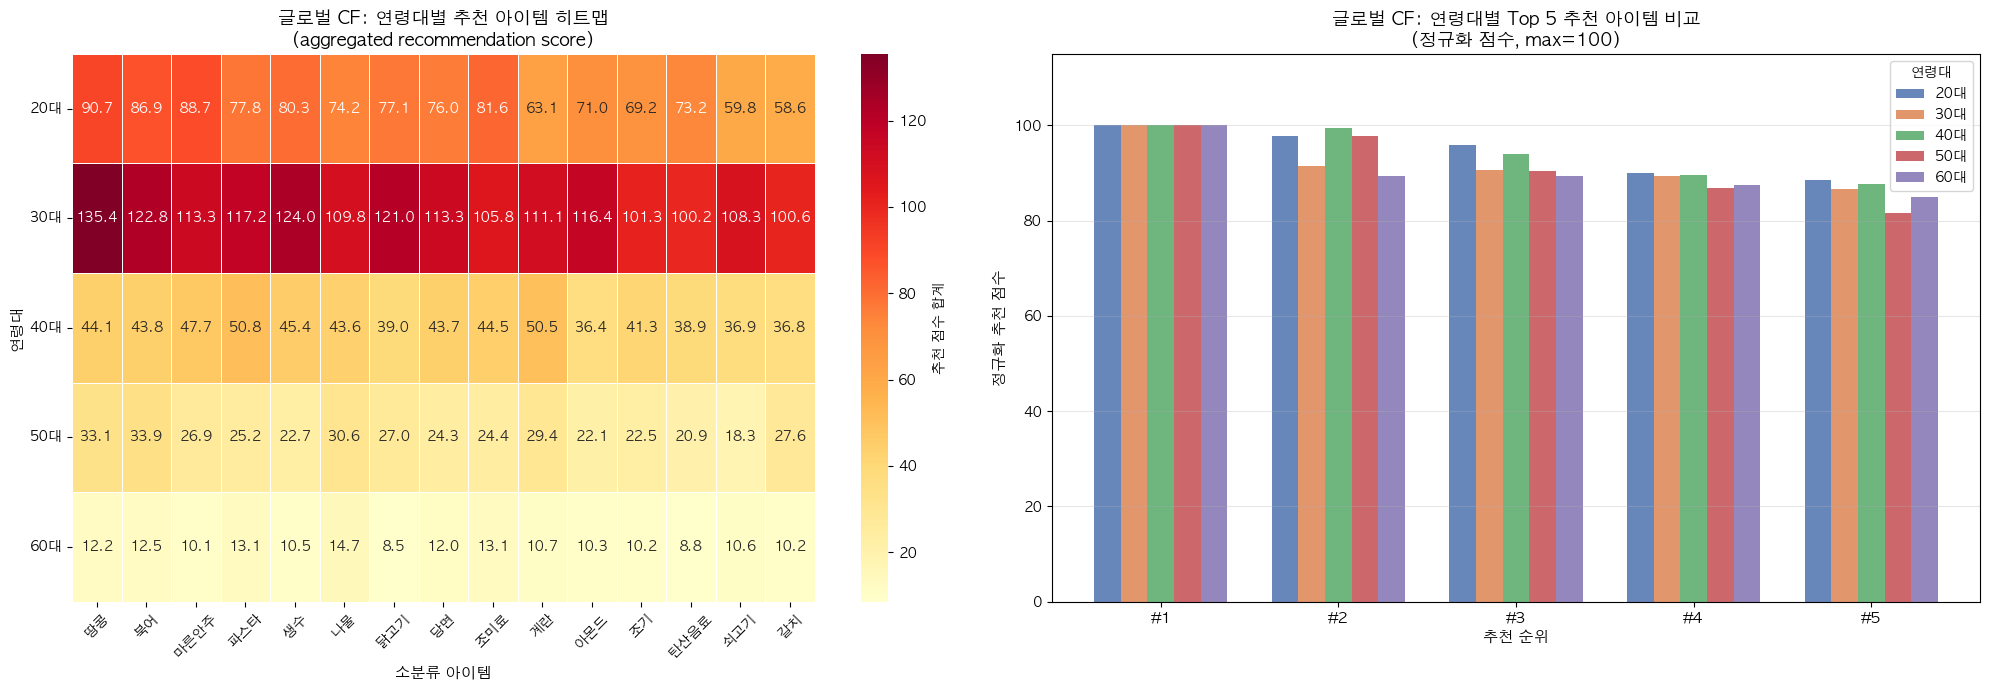

차트 저장: global_cf_age_group_analysis.png


In [27]:
# Cell 7: 시각화 - 연령대별 추천 아이템
# ============================================================

# --- 7-1: 히트맵 ---
top_n_viz = 15
# 모든 그룹 통합하여 top-15 아이템 추출
all_agg = pd.concat(age_group_recommendations_global.values()).groupby(level=0).sum()
top_items_global = all_agg.nlargest(top_n_viz).index.tolist()

heatmap_df = pd.DataFrame(
    {age: age_group_recommendations_global[age].reindex(top_items_global, fill_value=0)
     for age in age_groups}
).T  # shape: (5 age groups x top_n_viz items)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.heatmap(
    heatmap_df,
    ax=axes[0],
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': '추천 점수 합계'}
)
axes[0].set_title('글로벌 CF: 연령대별 추천 아이템 히트맵\n(aggregated recommendation score)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('소분류 아이템', fontsize=11)
axes[0].set_ylabel('연령대', fontsize=11)
axes[0].set_yticklabels([f'{age}대' for age in age_groups], rotation=0)
axes[0].tick_params(axis='x', rotation=45)

# --- 7-2: 그룹별 막대 차트 (top-5 per age group) ---
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
top5_per_group = {age: age_group_recommendations_global[age].head(5) for age in age_groups}

# 각 그룹 내에서 정규화 (max=100)
for age in age_groups:
    s = top5_per_group[age]
    max_s = s.max()
    top5_per_group[age] = (s / max_s * 100) if max_s > 0 else s

x_pos = np.arange(5)
bar_width = 0.15
offsets = np.linspace(-(len(age_groups)-1)/2, (len(age_groups)-1)/2, len(age_groups)) * bar_width

for i, (age, color) in enumerate(zip(age_groups, colors)):
    items  = top5_per_group[age].index.tolist()
    scores = top5_per_group[age].values
    bars = axes[1].bar(x_pos + offsets[i], scores, width=bar_width,
                       label=f'{age}대', color=color, alpha=0.85)

axes[1].set_title('글로벌 CF: 연령대별 Top 5 추천 아이템 비교\n(정규화 점수, max=100)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('추천 순위', fontsize=11)
axes[1].set_ylabel('정규화 추천 점수', fontsize=11)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'#{i+1}' for i in range(5)], fontsize=11)
axes[1].legend(title='연령대', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 115)

plt.tight_layout()
plt.savefig('global_cf_age_group_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("차트 저장: global_cf_age_group_analysis.png")

In [28]:
# Cell 8: 요약 인사이트
# ========================
# 글로벌 CF 분석 결과의 주요 발견사항

print('=' * 70)
print('  글로벌 협업필터링 (Global User-User Collaborative Filtering) 요약')
print('=' * 70)

print(f'\n[모델 설정]')
print(f'  - 알고리즘  : User-User Cosine Similarity CF (글로벌)')
print(f'  - 유사 사용자: Top-{TOP_K}명 기준 가중 평균 추천')
print(f'  - 추천 아이템: Top-{TOP_N}개')
print(f'  - 전체 사용자 : {len(all_users):,}명')
print(f'  - 아이템 수 : {global_matrix.shape[1]}개 (소분류)')
print(f'  - 평균 사용자 유사도: {global_sim[global_sim > 0].mean():.4f}')

print(f'\n[연령대별 추천 결과 Top 5]')
print('-' * 70)

# 깔끔한 요약 테이블
summary_rows = []
for age in age_groups:
    top5 = age_group_recommendations_global[age].head(5)
    users_in_age = [uid for uid in all_users if user_agegroup.get(uid) == age]
    n_users = len(users_in_age)
    row = {
        '연령대': f'{age}대',
        '사용자수': n_users,
        '1위': top5.index[0] if len(top5) > 0 else '-',
        '2위': top5.index[1] if len(top5) > 1 else '-',
        '3위': top5.index[2] if len(top5) > 2 else '-',
        '4위': top5.index[3] if len(top5) > 3 else '-',
        '5위': top5.index[4] if len(top5) > 4 else '-',
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('연령대')
print(summary_df.to_string())

# 연령대 간 추천 차별성
print(f'\n[연령대 간 추천 차별성 분석]')
print('-' * 70)
for age in age_groups:
    top5_items = set(age_group_recommendations_global[age].head(5).index)
    other_items = set().union(*[
        set(age_group_recommendations_global[a].head(5).index)
        for a in age_groups if a != age
    ])
    unique_to_age = top5_items - other_items
    print(f'  {age}대: Top5 중 고유 추천 = {len(unique_to_age)}개', end='')
    if unique_to_age:
        print(f' {list(unique_to_age)}')
    else:
        print(' (없음)')

print(f'\n[주요 특징 (글로벌 CF)]')
print('-' * 70)
print(f'  ✓ 전체 3,000명의 넓은 유사 사용자 풀 활용')
print(f'  ✓ 연령대를 사전 분리하지 않아 자연스러운 패턴 발견')
print(f'  ✓ 각 연령대의 추천 결과를 사후 분석하여 비교')
print(f'  ✓ 결과적으로 연령대별 선호도 차이를 포착 가능')

print(f'\n[인사이트]')
print('-' * 70)
for age in age_groups:
    top3 = age_group_recommendations_global[age].head(3).index.tolist()
    print(f'  {age}대: 글로벌 CF 추천 Top 3 → {" > ".join(top3)}')

print(f'\n  → 글로벌 협업필터링 기반 개인화 추천 시스템 수립 가능')
print(f'  → Cross-sell 및 상품 기획에 활용 가능')
print('=' * 70)

  글로벌 협업필터링 (Global User-User Collaborative Filtering) 요약

[모델 설정]
  - 알고리즘  : User-User Cosine Similarity CF (글로벌)
  - 유사 사용자: Top-20명 기준 가중 평균 추천
  - 추천 아이템: Top-5개
  - 전체 사용자 : 3,000명
  - 아이템 수 : 58개 (소분류)
  - 평균 사용자 유사도: 0.9155

[연령대별 추천 결과 Top 5]
----------------------------------------------------------------------
     사용자수   1위    2위    3위   4위   5위
연령대                                 
20대   820   땅콩  마른안주    북어  조미료   생수
30대  1280   땅콩    생수    북어  닭고기  파스타
40대   477  파스타    계란  마른안주   생수  조미료
50대   291   북어    땅콩    나물   계란   갈치
60대   132   나물   파스타   조미료  드레싱   북어

[연령대 간 추천 차별성 분석]
----------------------------------------------------------------------
  20대: Top5 중 고유 추천 = 0개 (없음)
  30대: Top5 중 고유 추천 = 1개 ['닭고기']
  40대: Top5 중 고유 추천 = 0개 (없음)
  50대: Top5 중 고유 추천 = 1개 ['갈치']
  60대: Top5 중 고유 추천 = 1개 ['드레싱']

[주요 특징 (글로벌 CF)]
----------------------------------------------------------------------
  ✓ 전체 3,000명의 넓은 유사 사용자 풀 활용
  ✓ 연령대를 사전 분리하지 않아 자연스러운 패턴 발견
  ✓ 각 연령대의 추천 결과를 사

In [29]:
# Cell 9: 개인별 추천 조회 함수 + 연령대별 샘플 사용자 추천 출력
# ==================================================================

def show_user_recommendation(user_id):
    """
    특정 사용자의 구매 이력과 개인화 추천을 출력하는 함수
    """
    if user_id not in user_agegroup:
        print(f"사용자 {user_id}를 찾을 수 없습니다.")
        return
    
    age = user_agegroup[user_id]
    user_idx = global_matrix.index.get_loc(user_id)
    purchased_items = global_matrix.columns[global_matrix.iloc[user_idx].astype(bool)].tolist()
    
    print(f"\n{'='*70}")
    print(f"[사용자 {user_id}] 연령대: {age}대")
    print(f"{'='*70}")
    print(f"구매 이력: {len(purchased_items)}개 아이템")
    print(f"  {', '.join(purchased_items[:10])}", end='')
    if len(purchased_items) > 10:
        print(f", ... 외 {len(purchased_items) - 10}개")
    else:
        print()
    
    print(f"{'-'*70}")
    print(f"추천 아이템 (Top-5):")
    
    if user_id in user_recommendations:
        recs = user_recommendations[user_id]
        for rank, (item, score) in enumerate(recs.items(), 1):
            print(f"  {rank}위. {item:<15s}  점수: {score:.4f}")
    else:
        print(f"  (추천 아이템 없음)")
    print(f"{'='*70}")


# 연령대별로 샘플 3명씩 개인 추천 출력
print("\n" + "#"*70)
print("# 연령대별 샘플 사용자 개인 추천")
print("#"*70)

for age in age_groups:
    users_in_age = [uid for uid in all_users if user_agegroup.get(uid) == age]
    sample_size = min(3, len(users_in_age))
    sample_users = np.random.choice(users_in_age, sample_size, replace=False)
    
    print(f"\n\n{'='*70}")
    print(f"[연령대 {age}대] {len(users_in_age)}명 중 {sample_size}명 샘플")
    print(f"{'='*70}")
    
    for sample_user in sample_users:
        show_user_recommendation(sample_user)


######################################################################
# 연령대별 샘플 사용자 개인 추천
######################################################################


[연령대 20대] 820명 중 3명 샘플

[사용자 U12316] 연령대: 20대
구매 이력: 53개 아이템
  갈치, 계란, 고구마, 고등어, 과일, 국수, 김, 김치, 나물, 낙지, ... 외 43개
----------------------------------------------------------------------
추천 아이템 (Top-5):
  1위. 파스타              점수: 0.7488
  2위. 생수               점수: 0.5489
  3위. 깻잎               점수: 0.1994
  4위. 콩나물              점수: 0.0997
  5위. 참외               점수: 0.0499

[사용자 U12884] 연령대: 20대
구매 이력: 57개 아이템
  갈치, 계란, 고구마, 고등어, 과일, 국수, 김, 김치, 깻잎, 나물, ... 외 47개
----------------------------------------------------------------------
추천 아이템 (Top-5):
  1위. 땅콩               점수: 0.7486
  2위. 갈치               점수: 0.0000
  3위. 계란               점수: 0.0000
  4위. 고구마              점수: 0.0000
  5위. 고등어              점수: 0.0000

[사용자 U11665] 연령대: 20대
구매 이력: 54개 아이템
  갈치, 계란, 고구마, 고등어, 과일, 국수, 김, 김치, 나물, 낙지, ... 외 44개
-------------------------

In [30]:
# Cell 10: 전체 사용자 개인 추천 결과를 DataFrame으로 저장
# ================================================================

# 전체 사용자의 개인 추천 결과를 DataFrame으로 구성
individual_recs_data = []

for user_id in all_users:
    age = user_agegroup.get(user_id, -1)
    user_idx = global_matrix.index.get_loc(user_id)
    purchased_count = global_matrix.iloc[user_idx].sum()
    
    # 추천 아이템 Top-5 추출
    if user_id in user_recommendations:
        recs = user_recommendations[user_id]
        rec_items = list(recs.index)
        rec_scores = list(recs.values)
    else:
        rec_items = ['-'] * 5
        rec_scores = [0.0] * 5
    
    # 5개 미만인 경우 '-'로 채우기
    while len(rec_items) < 5:
        rec_items.append('-')
        rec_scores.append(0.0)
    
    row = {
        'idUser': user_id,
        'AgeGroup': f'{age}대',
        '구매아이템수': int(purchased_count),
        '추천1위': rec_items[0],
        '추천1위_점수': rec_scores[0],
        '추천2위': rec_items[1],
        '추천2위_점수': rec_scores[1],
        '추천3위': rec_items[2],
        '추천3위_점수': rec_scores[2],
        '추천4위': rec_items[3],
        '추천4위_점수': rec_scores[3],
        '추천5위': rec_items[4],
        '추천5위_점수': rec_scores[4],
    }
    individual_recs_data.append(row)

individual_recommendations_df = pd.DataFrame(individual_recs_data)

# CSV 저장
individual_recommendations_df.to_csv('individual_cf_recommendations.csv', index=False, encoding='utf-8-sig')

print(f"\n{'='*70}")
print("전체 사용자 개인 추천 결과 저장 완료")
print(f"{'='*70}")
print(f"총 사용자 수: {len(individual_recommendations_df):,}명")
print(f"\n샘플 (처음 5명):")
print(individual_recommendations_df[['idUser', 'AgeGroup', '구매아이템수', '추천1위', '추천2위', '추천3위']].head().to_string(index=False))
print(f"\n파일 저장: individual_cf_recommendations.csv")

# 연령대별 통계
print(f"\n{'='*70}")
print("연령대별 통계")
print(f"{'='*70}")
age_stats = individual_recommendations_df.groupby('AgeGroup').agg({
    'idUser': 'count',
    '구매아이템수': ['mean', 'min', 'max']
}).round(1)
age_stats.columns = ['사용자수', '평균구매', '최소구매', '최대구매']
print(age_stats.to_string())


전체 사용자 개인 추천 결과 저장 완료
총 사용자 수: 3,000명

샘플 (처음 5명):
idUser AgeGroup  구매아이템수 추천1위 추천2위    추천3위
U10001      20대      55   국수   땅콩      북어
U10002      60대      48 블루베리   나물     드레싱
U10003      30대      49   멸치 돼지고기      북어
U10004      20대      40   과일  드레싱 혼합및이온음료
U10005      30대      53   땅콩   나물      당면

파일 저장: individual_cf_recommendations.csv

연령대별 통계
          사용자수  평균구매  최소구매  최대구매
AgeGroup                        
20대        820  51.6    32    58
30대       1280  51.5    29    58
40대        477  51.8    40    57
50대        291  51.8    36    58
60대        132  51.7    31    57
